In [15]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr, spearmanr

In [16]:
full_data_scan = pd.read_csv("../data/results.csv")
full_data_bench = pd.read_csv("../data/results_benchmark.csv")

In [17]:
# Calculate to which quantile each molecule in the dataset belongs.

top1_vina = full_data_scan["vina_score"] <= full_data_scan["vina_score"].quantile(q=0.01, interpolation='linear')
top1_mmgbsa = full_data_scan["mmgbsa_score"] <= full_data_scan["mmgbsa_score"].quantile(q=0.01, interpolation='linear')
top1_both = top1_vina & top1_mmgbsa

full_data_scan = full_data_scan
full_data_scan["species"] = "Dataset"
full_data_scan.loc[top1_vina,"species"] = "Vina Top-1%"
full_data_scan.loc[top1_mmgbsa,"species"] = "MMGBSA Top-1%"
full_data_scan.loc[top1_both,"species"] = "Overlap"

In [18]:
def plot_2d_hist(data, benchmark, ax, fontsize=12):
    palette = sns.color_palette(palette=['#4c72b0', '#dd8452', '#55a868', '#da8bc3'])
    
    ax.set_box_aspect(1)

    # First y-axis
    sns.histplot(
        data=data,
        y='mmgbsa_score',
        x='vina_score',
        ax=ax,
        hue="species",
        hue_order=["Dataset","Vina Top-1%","Overlap","MMGBSA Top-1%"],
        binwidth=(0.1,0.5),
        legend=True,
        palette=palette
    )

    # Plot experimental binders
    color_benchmark = sns.color_palette()[3]
    sns.regplot(
        data=benchmark,
        y='mmgbsa_score_blind',
        x='vina_score_blind',
        ax=ax,
        fit_reg=False,
        marker="x",
        scatter_kws={'linewidths':1.5},
        label="Experimental Binders",
        color=color_benchmark
    )

    # Mark 1% quantiles
    ax.axvline(data["vina_score"].quantile(q=0.01, interpolation='linear')+0.02, ls='--', c='grey')
    ax.axhline(data["mmgbsa_score"].quantile(q=0.01, interpolation='linear'), ls='--', c='grey')

    # Axis labels and title
    ax.set_xlabel("ΔG Vina [kcal/mol]", fontsize=fontsize)
    ax.set_ylabel("ΔG MMGBSA [kcal/mol]", fontsize=fontsize)
    ax.tick_params(axis='x')
    ax.set_title("MMGBSA vs Vina", fontsize=fontsize, fontweight='bold')

    # Legend
    legend = ax.get_legend()
    handles = legend.legend_handles
    handle_benchmark_binders = matplotlib.lines.Line2D([0], [0], marker='x', ls="", color=color_benchmark)
    
    ax.legend(
        handles + [handle_benchmark_binders],
        ["Dataset","Vina Top-1%","Overlap","MMGBSA Top-1%", "Experimental Binder"],
        title='',
        loc='upper left',
        fontsize=fontsize-6
    )
    

In [19]:
def plot_correlation_vina(benchmark, ax, fontsize=12):
    color = sns.color_palette()[0]

    # First y-axis
    ax.set_box_aspect(1)
    ax.errorbar(
        benchmark["exp_dg"],
        benchmark["vina_score_blind"],
        xerr=benchmark["exp_dg_error"],
        fmt=".",
        label='Vina',
        color=color
    )

    pearson_gb, _ = pearsonr(benchmark['exp_dg'], benchmark['vina_score_blind'])
    spearman_gb, _ = spearmanr(benchmark['exp_dg'], benchmark['vina_score_blind'])
    sns.regplot(
        data=benchmark,
        x='exp_dg', y='vina_score_blind',
        ax=ax,
        scatter=False,
        ci=None,
        label=f"Pearsonr={pearson_gb:.3f}\nSpearmanr={spearman_gb:.3f}",
        truncate=False,
        color=color
    )

    ax.set_ylabel("ΔG Vina [kcal/mol]", fontsize=fontsize)
    ax.tick_params(axis='y')

    # Labels and Title
    ax.set_xlabel("ΔG Experimental [kcal/mol]", fontsize=fontsize)
    ax.set_title("Experimental vs Vina", fontsize=fontsize, fontweight='bold')
    ax.legend(loc='upper left', fontsize=fontsize-6)

In [20]:
def plot_correlation_mmgbsa(benchmark, ax, fontsize=12):
    color = sns.color_palette()[0]

    # First y-axis
    ax.set_box_aspect(1)
    ax.errorbar(
        benchmark["exp_dg"],
        benchmark["mmgbsa_score_blind"],
        xerr=benchmark["exp_dg_error"],
        yerr=benchmark["mmgbsa_score_blind_sem"],
        fmt=".",
        label='MMGBSA',
        color=color
    )

    pearson_gb, _ = pearsonr(benchmark['exp_dg'], benchmark['mmgbsa_score_blind'])
    spearman_gb, _ = spearmanr(benchmark['exp_dg'], benchmark['mmgbsa_score_blind'])
    sns.regplot(
        data=benchmark,
        x='exp_dg', y='mmgbsa_score_blind',
        ax=ax,
        scatter=False,
        ci=None,
        label=f"Pearsonr={pearson_gb:.3f}\nSpearmanr={spearman_gb:.3f}",
        truncate=False,
        color=color
    )

    ax.set_ylabel("ΔG MMGBSA [kcal/mol]", fontsize=fontsize)
    ax.tick_params(axis='y')

    # Labels and Title
    ax.set_xlabel("ΔG Experimental [kcal/mol]", fontsize=fontsize)
    ax.set_title("Experimental vs MMGBSA", fontsize=fontsize, fontweight='bold')
    ax.legend(loc='upper left', fontsize=fontsize-6)

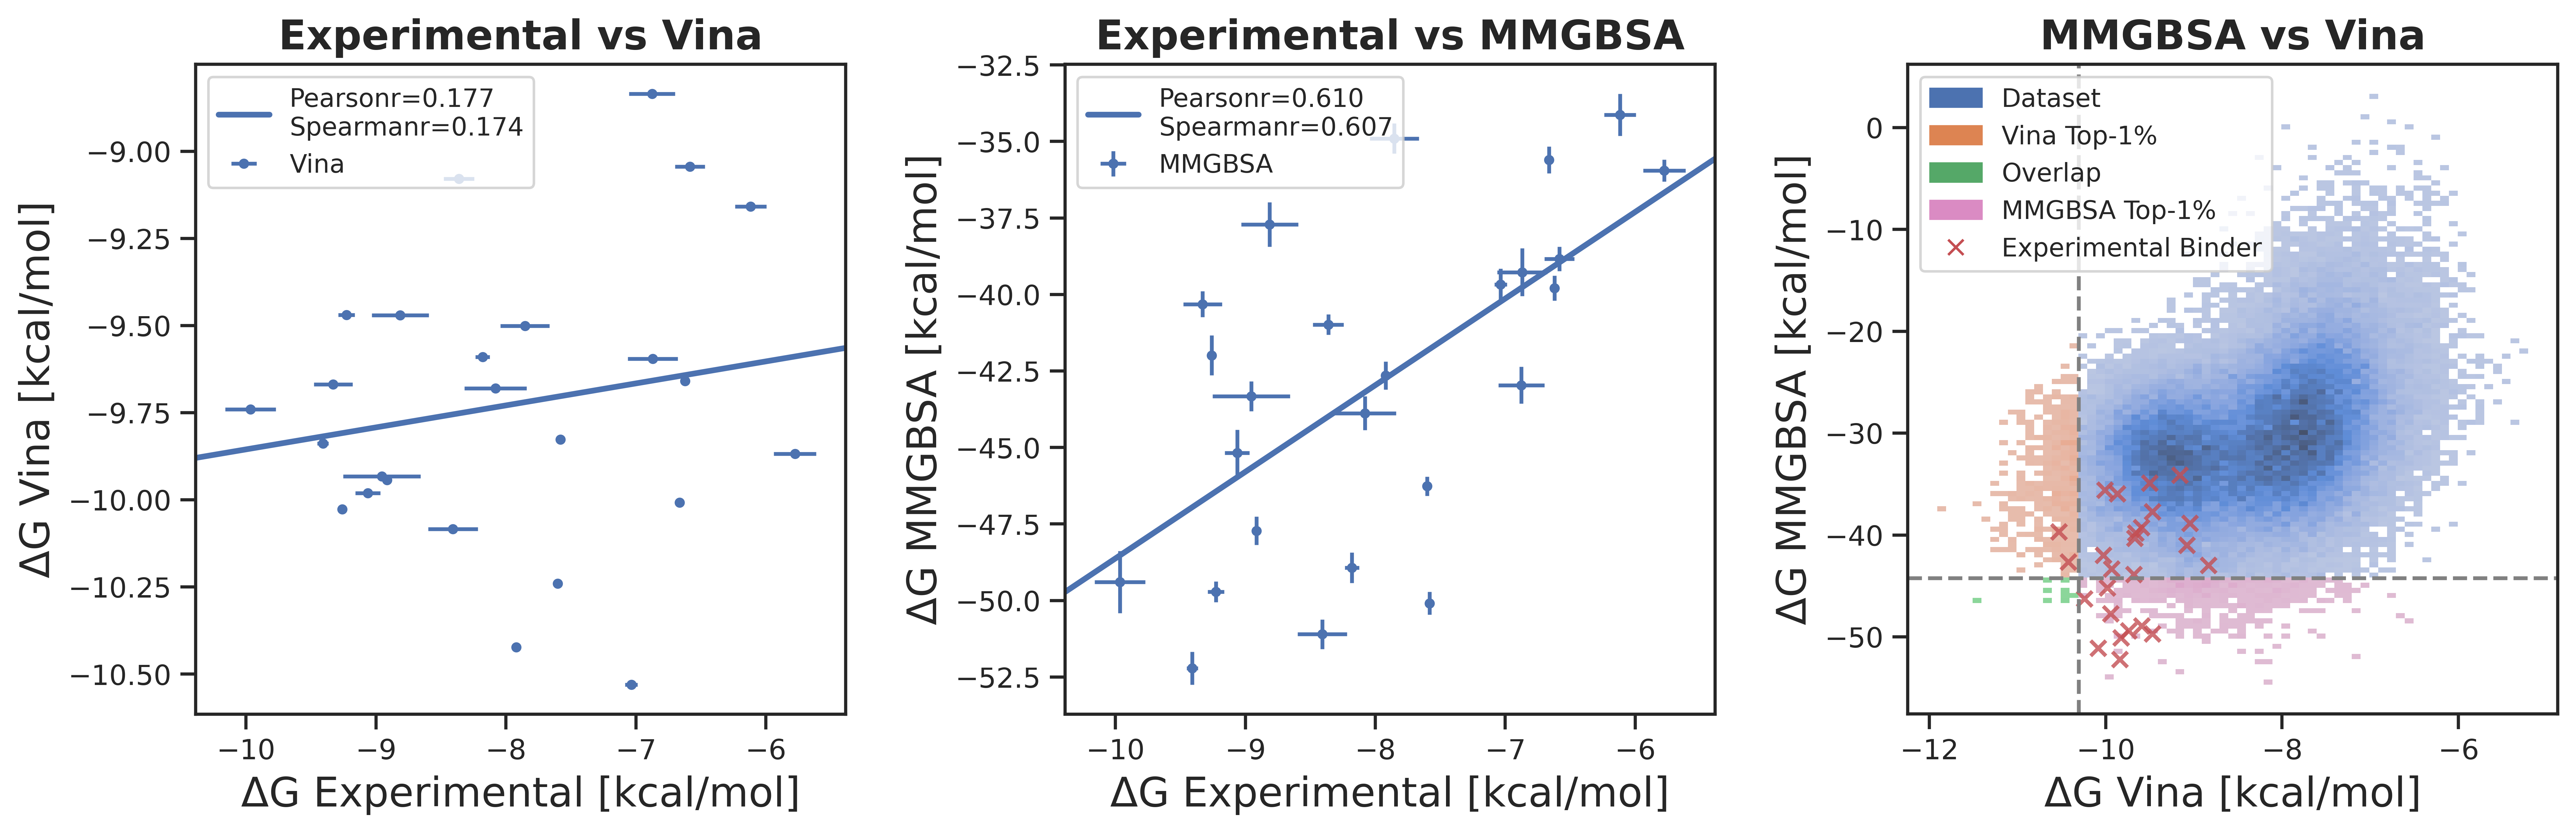

In [21]:

fontsize = 16
with plt.rc_context({'font.size': fontsize, "figure.dpi": 600}):
    sns.set(style="ticks")
    fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(14, 14/3), constrained_layout=True)
    plot_correlation_vina(
        benchmark=full_data_bench, ax=ax1, fontsize=fontsize
    )

    plot_correlation_mmgbsa(
        benchmark=full_data_bench, ax=ax2, fontsize=fontsize
    )
    
    plot_2d_hist(
        data=full_data_scan,
        benchmark=full_data_bench,
        ax=ax3,
        fontsize=fontsize
    )
    
    fig.get_layout_engine().set(w_pad=4 / 72, h_pad=4 / 72, hspace=0.02, wspace=0.07)
    plt.savefig("figures/PAPER_composite.png",dpi=1000,transparent=True, bbox_inches = "tight")
    plt.show()